# FC and PF (Multi-condition measurements) at 10 K

**Device:** FGT-OFGT-CrPS4

**Data folder:** `data/Device2/Field_Cooling_Experiment/10K`  
**Measurement:** FC at 0.5T, 1T, 8T and ZFC pre-field 1T, all at 10 K.  


---

In [3]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import sys
sys.path.insert(0, str(Path().resolve().parent))
from scripts.data_loader import (
    load_h5, load_txt, get_file_list,
    offset_and_AHE, normalize,
    coercivity_zero_crossing, coercivity_largest_jump,
    exchange_bias, coercive_width,
    sort_serial, fixjump,
)
from scripts.notebook_setup import setup
setup()

PROJECT_ROOT = Path().resolve().parent
D2 = PROJECT_ROOT / 'data' / 'Device2'

[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


In [16]:
FOLDER_10K = D2 / 'Field_Cooling_Experiment' / '10K'
LEGENDS    = ['FC 0.5 T', 'FC 1 T', 'FC 8 T', 'PF 1 T']

T_fc, H1_fc, H2_fc, H1_zc, H2_zc = [], [], [], [], []
Field_fc, Vxy_fc, Vxy_err_fc, Vxx_fc, Vxx_err_fc = [], [], [], [], []
Vxy_norm_fc, Vahe_fc, R_fc = [], [], []
ZFC_idx, FC_idx = [], []

filelist_fc = get_file_list(FOLDER_10K, ext=('.h5',))

for idx, fp in enumerate(filelist_fc):
    d = load_h5(fp, channel_xy=2, P=1)
    F    = d['Field'];  Sig  = d['Vxy'];  ref  = d['Vxx']
    Serr = d['Vxy_err'];  Rerr = d['Vxx_err'];  T = d['T']

    # channel auto-select: keep the larger-amplitude signal as Hall
    if (np.max(Sig) - np.min(Sig)) < (np.max(ref) - np.min(ref)):
        Sig, ref = ref.copy(), Sig.copy()
        Serr, Rerr = Rerr.copy(), Serr.copy()

    # Simple midpoint normalisation (matches original script)
    midpoint = (np.max(Sig) + np.min(Sig)) / 2
    Sig_norm = Sig - midpoint


    # ── Zero-crossing coercivity (alternative) ────────────────────────────────
    offset, _, Vahe, _ = offset_and_AHE(Sig)
    Sig_norm_zc = normalize(Sig, offset, Vahe)
    HC_neg_zc, HC_pos_zc = coercivity_zero_crossing(F, Sig_norm_zc)

    T_fc.append(T)
    H1_zc.append(HC_neg_zc);  H2_zc.append(HC_pos_zc)
    Field_fc.append(F);  Vxy_fc.append(Sig);  Vxy_err_fc.append(Serr)
    Vxx_fc.append(ref);  Vxx_err_fc.append(Rerr)
    Vxy_norm_fc.append(Sig_norm);  Vahe_fc.append(midpoint)

    peak = np.max(ref);  mask = np.abs(ref - peak) < 0.5
    R_fc.append(np.mean(ref[mask]) if mask.any() else peak)

    if fp.name.startswith('Z'):
        ZFC_idx.append(idx)
    else:
        FC_idx.append(idx)

    """
    # ── F1 per file: Temperature (VTI) vs Field ───────────────────────────────
    # (VTIT not stored by load_h5 per-point — reproduce from d['VTIT'] scalar)
    plt.figure()
    plt.axhline(d['VTIT'], color='b', label=f'VTIT = {d["VTIT"]:.1f} K')
    plt.xlabel('Index')
    plt.ylabel('Temperature (K)')
    plt.title(f'Temperature: {T} K')
    plt.legend()
    plt.tight_layout()
    plt.show()
    """
    """
    # ── F2 per file: Vxy vs B ─────────────────────────────────────────────────
    plt.figure()
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Vxy (uV)')
    plt.title(f'Temperature: {T} K')
    plt.plot(F, Sig)
    plt.errorbar(F, Sig, Serr, fmt='o')
    plt.tight_layout()
    plt.show()
    """
    
    """
    # ── F3 per file: Vxx vs B ─────────────────────────────────────────────────
    plt.figure()
    plt.xlabel('Magnetic Field (mT)')
    plt.ylabel('Vxx (uV)')
    plt.title(f'Temperature: {T} K')
    plt.plot(F, ref)
    plt.errorbar(F, ref, Rerr, fmt='o')
    plt.tight_layout()
    plt.show()
    """
T_fc   = np.array(T_fc)
H1_fc  = np.array(H1_fc);  H2_fc  = np.array(H2_fc)
H1_zc  = np.array(H1_zc);  H2_zc  = np.array(H2_zc)
R_fc   = np.array(R_fc)
ZFC_idx = np.array(ZFC_idx);  FC_idx = np.array(FC_idx)

W_zc   = np.abs(H1_zc - H2_zc) / 2
HEB_zc = (H1_zc + H2_zc) / 2

print('Zero-cross   H_EB (mT):', [f'{v:.1f}' for v in HEB_zc])

Zero-cross   H_EB (mT): ['-2.5', '-2.5', '-12.7', '-38.0']


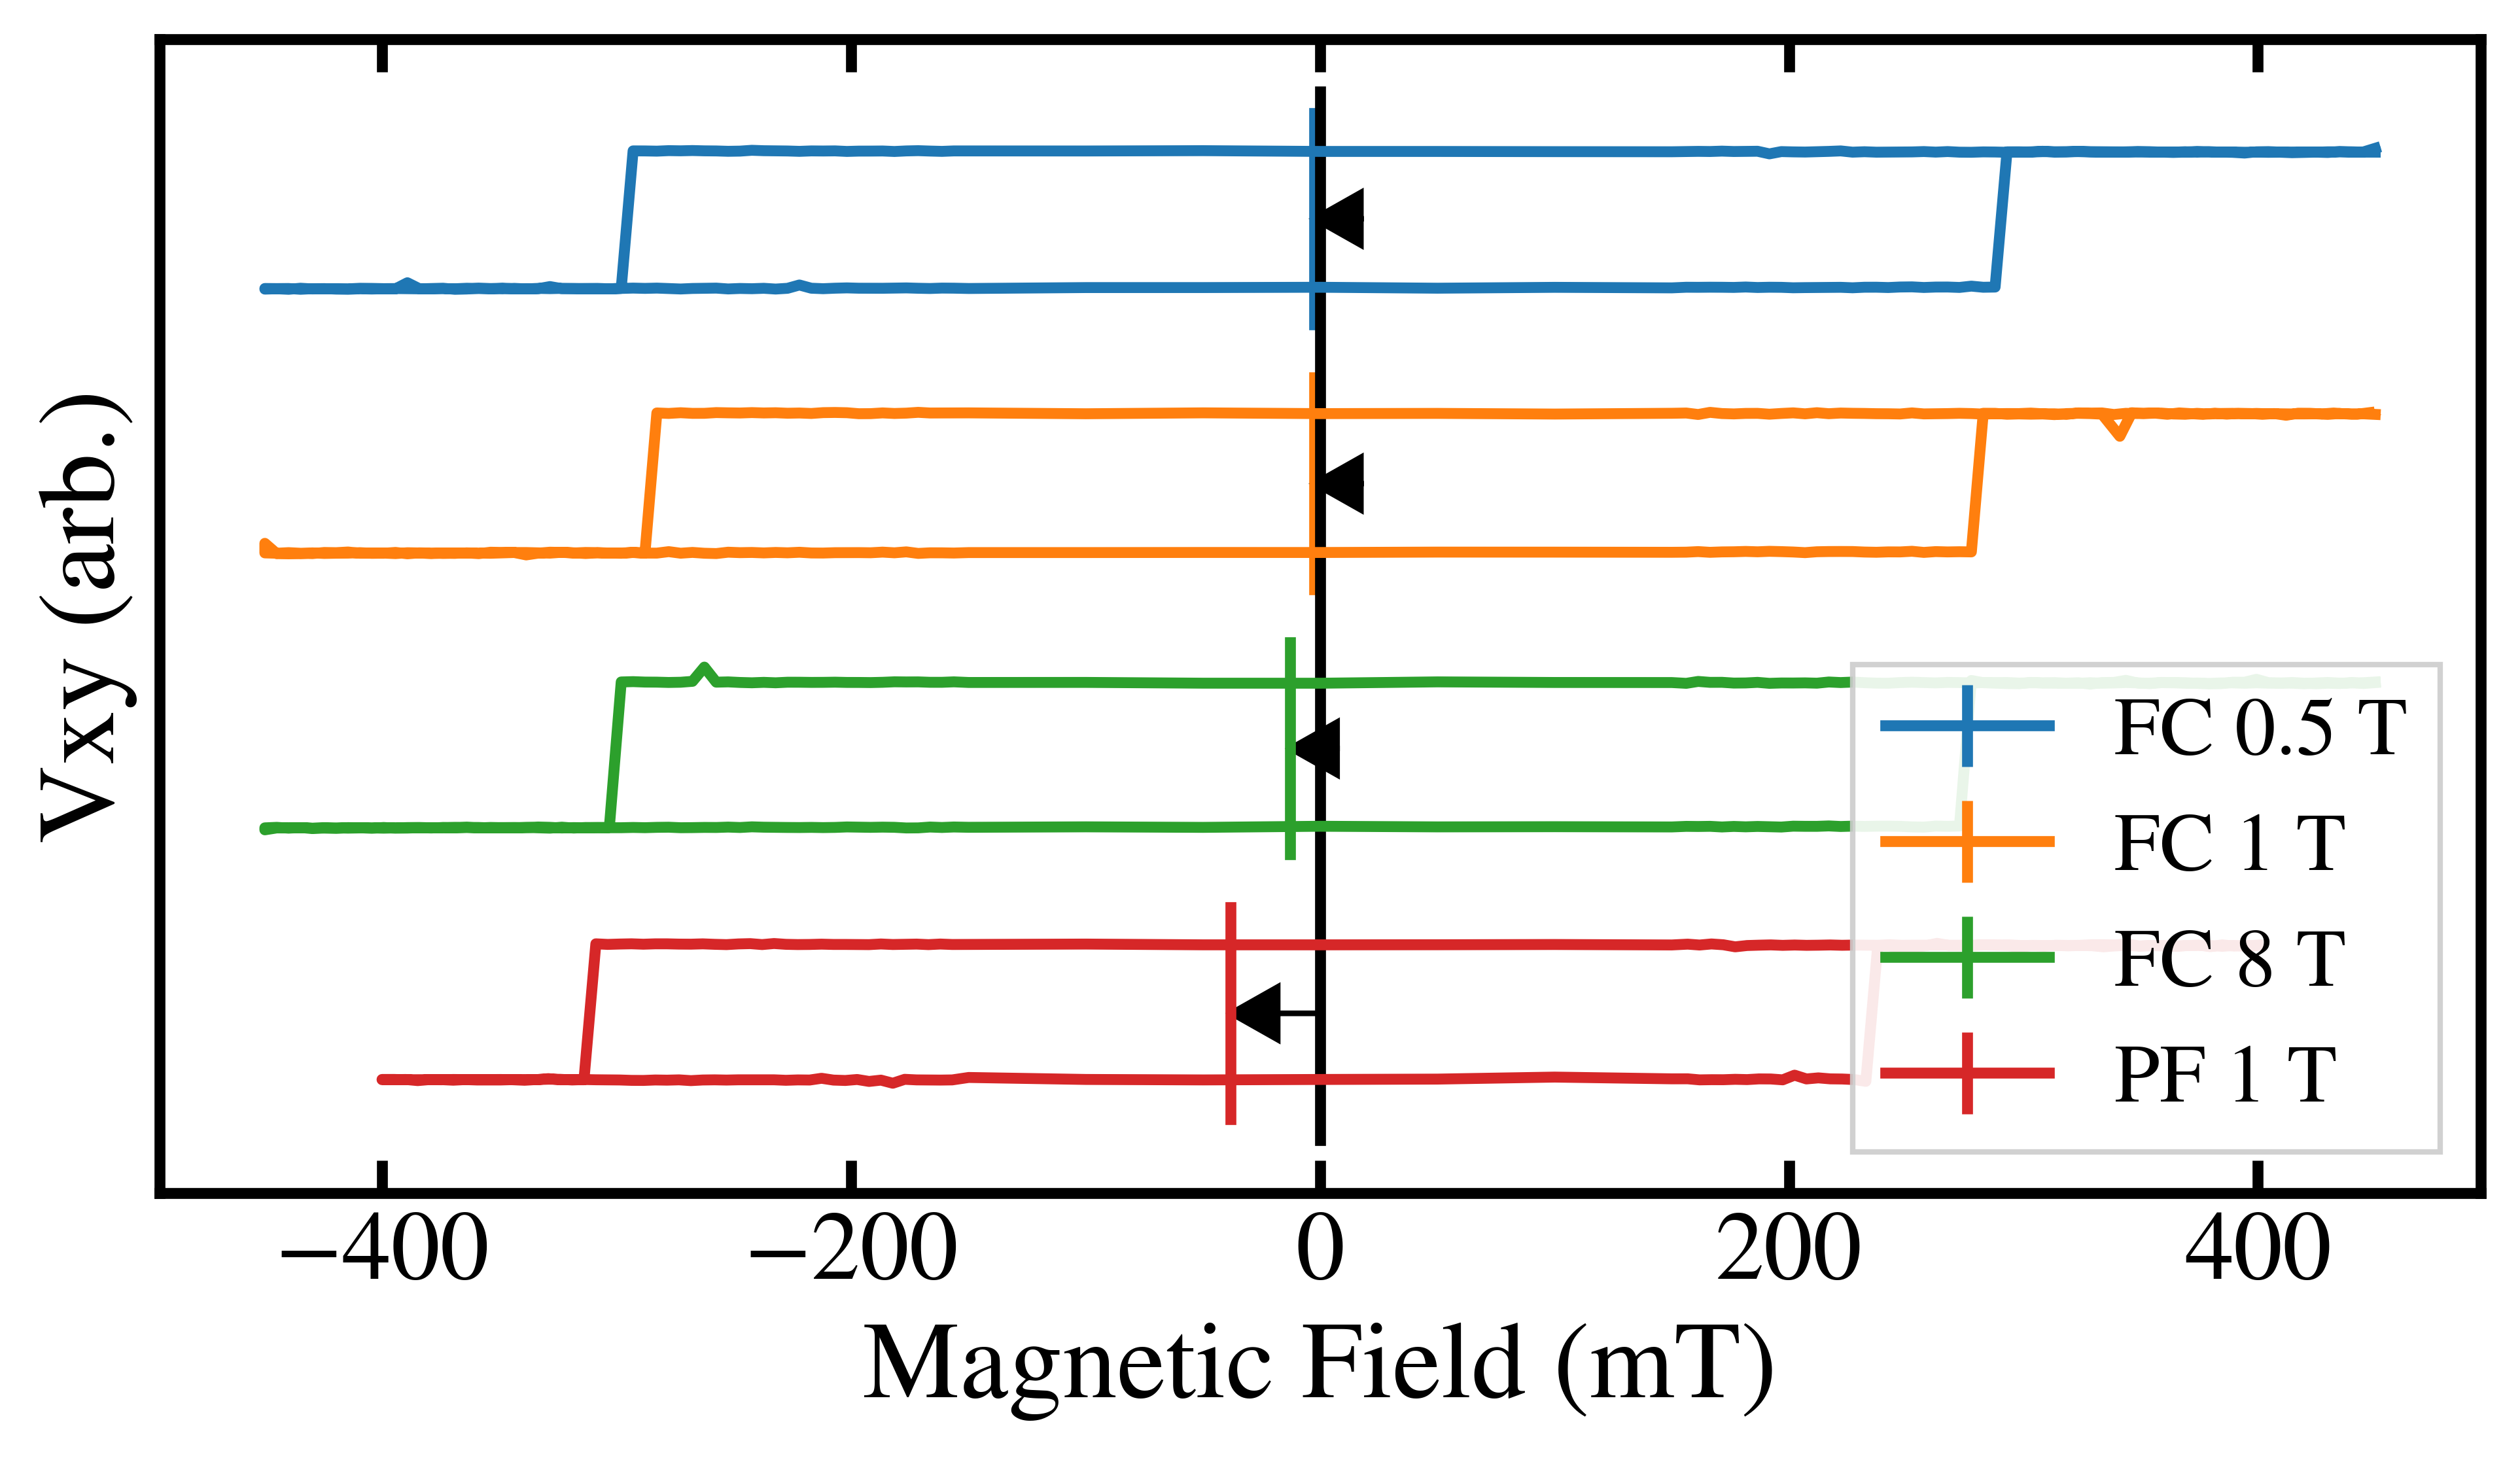

In [17]:
# ── F6: Waterfall — all conditions ────────────────────────────────────────────
# figsize=(6.7,4), cm.tab10, arrows, yticks([])
plt.figure(figsize=(6.7, 4), dpi=600)
plt.xlabel('Magnetic Field (mT)', fontsize=20)
plt.ylabel('Vxy (arb.)', fontsize=20)
for i in range(len(T_fc)):
    off = i * -2.5
    plt.errorbar(
        Field_fc[i], Vxy_norm_fc[i] + off,
        Vxy_err_fc[i] / Vahe_fc[i],
        fmt='-', markersize=3, label=LEGENDS[i], color=cm.tab10(i / 10),
    )
    plt.plot([HEB_zc[i], HEB_zc[i]], [off + 1, off - 1], color=cm.tab10(i / 10))
    plt.arrow(0, off, HEB_zc[i], 0, head_width=0.5, head_length=20,
              length_includes_head=True, color='black')
plt.plot([0, 0], [1.2, (len(T_fc) - 1) * -2.5 - 1.2], 'k')
plt.legend(loc='lower right', fontsize=15)
plt.yticks([])
plt.tight_layout()
plt.show()

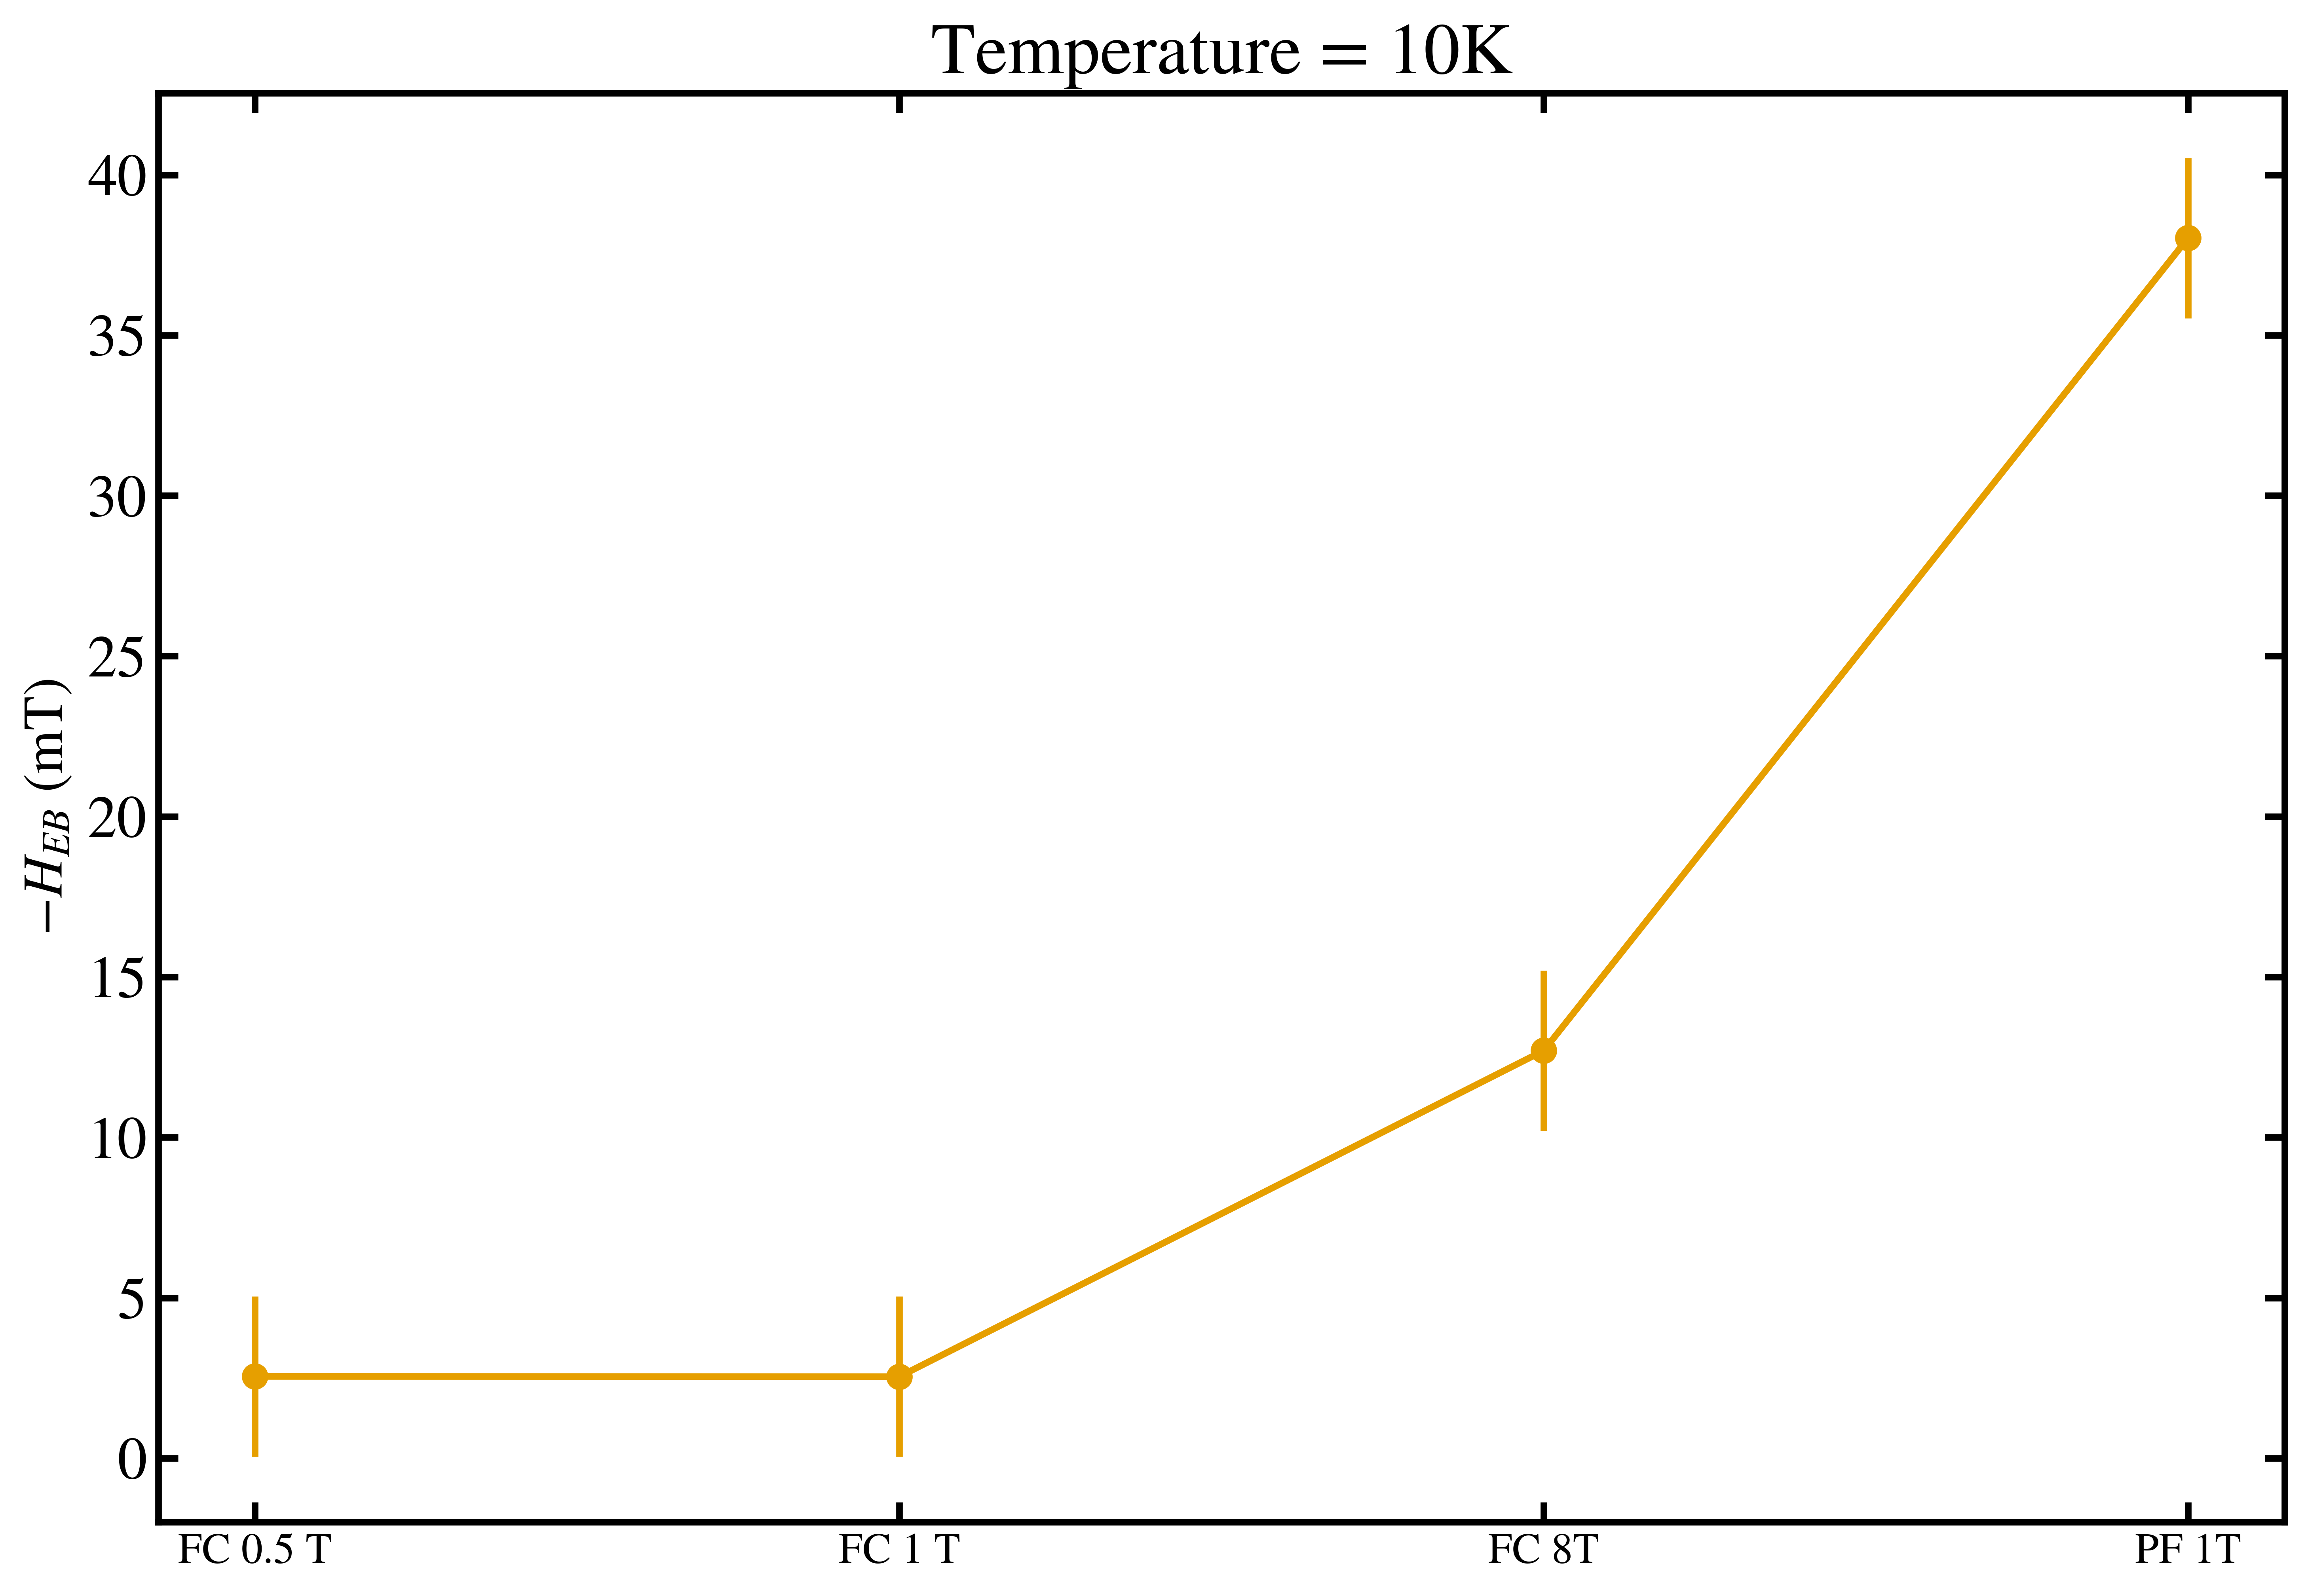

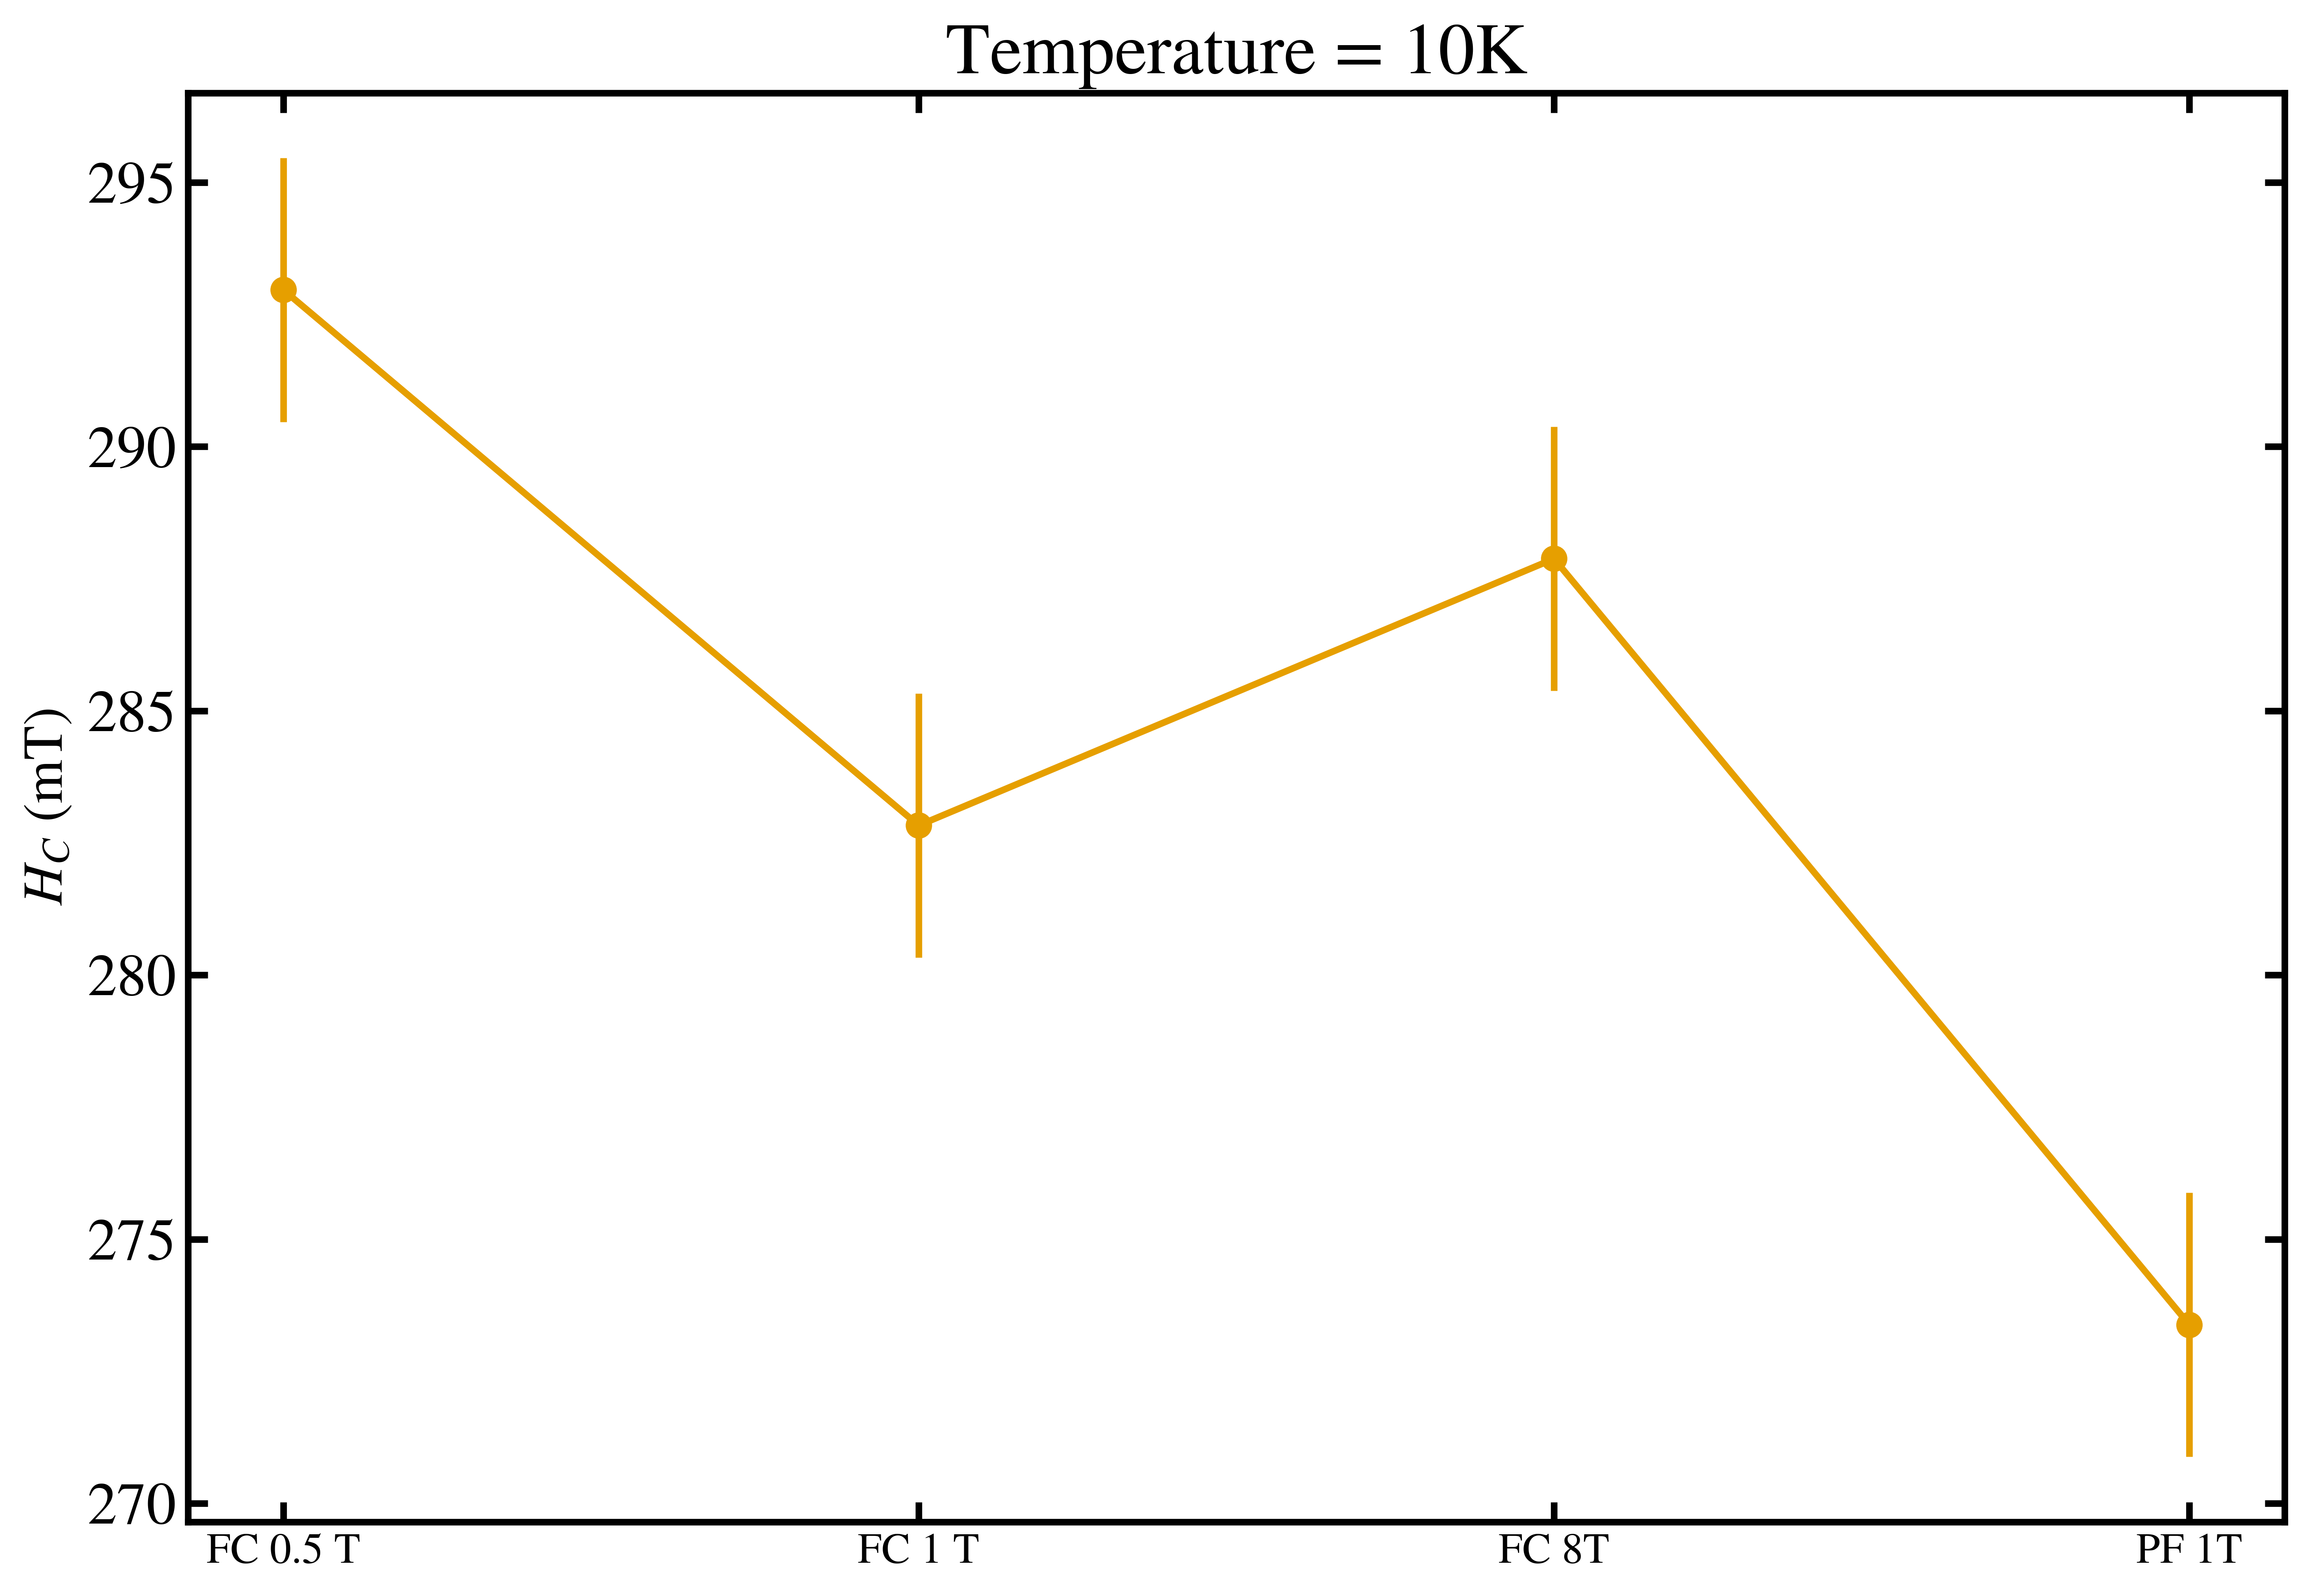

In [19]:
xl = ['FC 0.5 T', 'FC 1 T', 'FC 8T', 'PF 1T']

# ── F8: −H_EB vs condition ────────────────────────────────────────────────────
plt.figure(dpi=600)
plt.errorbar(xl, -1 * HEB_zc, 2.5, fmt='-o')
plt.ylabel('$-H_{EB}$ (mT)', fontsize=17)
plt.title('Temperature = 10K')
plt.xticks(fontsize=13)
plt.tight_layout()
plt.show()

# ── F9: H_C vs condition ──────────────────────────────────────────────────────
plt.figure(dpi=600)
plt.errorbar(xl, W_zc, 2.5, fmt='-o')
plt.ylabel('$H_C$ (mT)', fontsize=17)
plt.title('Temperature = 10K')
plt.xticks(fontsize=13)
plt.tight_layout()
plt.show()